# Claim Severity EDA

## Objective

The goal of this notebook is to understand the factors related to claim severity.

Claim severity represents the financial size of a claim.

The target variable is `damage_amount`.

The dataset comes from the `vw_auto_claim_severity_ml` SQL view and contains valid Auto insurance claims.

The analysis will focus on:

- data quality,
- target distribution,
- important feature relationships,
- the final feature engineering strategy.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [5]:
conn = pyodbc.connect(
    "DSN=InsuranceAnalytics;",
    autocommit=True
)

query = """
SELECT *
FROM vw_auto_claim_severity_ml
"""

severity_df = pd.read_sql(
    query,
    conn,
)

severity_df["occurrence_date"] = pd.to_datetime(
    severity_df["occurrence_date"]
)

severity_df["declaration_date"] = pd.to_datetime(
    severity_df["declaration_date"]
)

In [6]:
print("Shape:", severity_df.shape)

print(
    "Unique claims:",
    severity_df["claim_id"].nunique(),
)

print(
    "Average damage:",
    round(severity_df["damage_amount"].mean(), 2),
)

print(
    "Median damage:",
    round(severity_df["damage_amount"].median(), 2),
)

print(
    "Min damage:",
    round(severity_df["damage_amount"].min(), 2),
)

print(
    "Max damage:",
    round(severity_df["damage_amount"].max(), 2),
)

Shape: (109, 24)
Unique claims: 109
Average damage: 4120.18
Median damage: 2102.55
Min damage: 190.01
Max damage: 19682.88


## Initial Target Overview

The severity dataset contains 109 valid Auto claims.

The average damage amount is higher than the median damage amount. This suggests that the target may have a right-skewed distribution.

The target distribution will be examined in more detail before deciding whether a transformation is needed.

## Data Quality Check

Before analyzing claim severity, we check:

- duplicate claims,
- missing values,
- data types,
- invalid numeric values,
- invalid claim dates.

In [7]:
print("Dataset shape:", severity_df.shape)

print(
    "Duplicate rows:",
    severity_df.duplicated().sum()
)

print(
    "Duplicate claim IDs:",
    severity_df["claim_id"].duplicated().sum()
)

severity_df.info()

Dataset shape: (109, 24)
Duplicate rows: 0
Duplicate claim IDs: 0
<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype        
---  ------                --------------  -----        
 0   claim_id              109 non-null    str          
 1   contract_id           109 non-null    str          
 2   occurrence_date       109 non-null    datetime64[s]
 3   declaration_date      108 non-null    datetime64[s]
 4   declaration_lag_days  108 non-null    float64      
 5   claim_type            109 non-null    str          
 6   annual_premium        109 non-null    float64      
 7   city                  109 non-null    str          
 8   risk_zone             109 non-null    str          
 9   client_age            98 non-null     float64      
 10  channel               109 non-null    str          
 11  csp                   100 non-null    str          
 12  gender                93 non-null    

In [8]:
missing_summary = (
    severity_df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(severity_df)
    * 100
)

missing_summary = (
    missing_summary
    .loc[missing_summary["missing_count"] > 0]
    .sort_values(
        "missing_pct",
        ascending=False,
    )
)

missing_summary

,missing_count,missing_pct
power_hp,20,18.3486
color,17,15.5963
gender,16,14.6789
client_age,11,10.0917
previous_claims,11,10.0917
csp,9,8.2569
year,6,5.5046
vehicle_age_at_claim,6,5.5046
declaration_lag_days,1,0.9174
declaration_date,1,0.9174


In [9]:
quality_checks = pd.Series(
    {
        "damage_le_zero": (
            severity_df["damage_amount"] <= 0
        ).sum(),

        "premium_le_zero": (
            severity_df["annual_premium"] <= 0
        ).sum(),

        "client_age_below_18": (
            severity_df["client_age"] < 18
        ).sum(),

        "client_age_above_100": (
            severity_df["client_age"] > 100
        ).sum(),

        "power_hp_le_zero": (
            severity_df["power_hp"] <= 0
        ).sum(),

        "current_value_le_zero": (
            severity_df["current_value"] <= 0
        ).sum(),

        "previous_claims_below_zero": (
            severity_df["previous_claims"] < 0
        ).sum(),

        "negative_declaration_lag": (
            severity_df["declaration_lag_days"] < 0
        ).sum(),

        "declaration_before_occurrence": (
            severity_df["declaration_date"]
            < severity_df["occurrence_date"]
        ).sum(),
    }
)

quality_checks

damage_le_zero                   0
premium_le_zero                  0
client_age_below_18              0
client_age_above_100             0
power_hp_le_zero                 0
current_value_le_zero            0
previous_claims_below_zero       0
negative_declaration_lag         0
declaration_before_occurrence    0
dtype: int64

### Data Quality Results

The severity dataset contains 109 unique claims and no duplicate records.

No invalid values were found for damage amount, premium, client age, vehicle power, vehicle value, previous claims, or claim dates.

Some customer and vehicle features contain missing values. These missing values will be handled during preprocessing.

The dataset is ready for target and feature analysis.

In [10]:
damage_summary = severity_df["damage_amount"].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

damage_summary

count      109.0000
mean     4,120.1822
std      4,933.1970
min        190.0100
10%        340.6080
25%        848.0000
50%      2,102.5500
75%      4,806.7800
90%     13,141.1900
95%     14,806.6640
99%     19,052.9704
max     19,682.8800
Name: damage_amount, dtype: float64

In [11]:
damage_skewness = severity_df["damage_amount"].skew()

print(
    "Damage skewness:",
    round(damage_skewness, 4),
)

Damage skewness: 1.6655


In [12]:
q1 = severity_df["damage_amount"].quantile(0.25)
q3 = severity_df["damage_amount"].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

high_damage_count = (
    severity_df["damage_amount"]
    > upper_bound
).sum()

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Upper bound:", round(upper_bound, 2))
print("High damage claims:", high_damage_count)

Q1: 848.0
Q3: 4806.78
IQR: 3958.78
Upper bound: 10744.95
High damage claims: 16


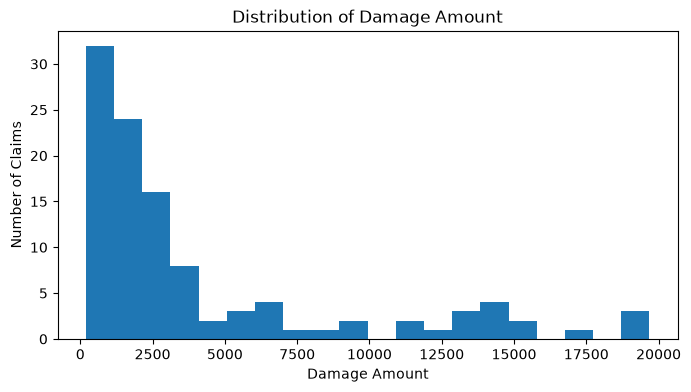

In [13]:
plt.figure(figsize=(8, 4))

plt.hist(
    severity_df["damage_amount"],
    bins=20,
)

plt.title("Distribution of Damage Amount")
plt.xlabel("Damage Amount")
plt.ylabel("Number of Claims")

plt.show()

In [14]:
severity_df["log_damage_amount"] = np.log1p(
    severity_df["damage_amount"]
)

print(
    "Raw skewness:",
    round(
        severity_df["damage_amount"].skew(),
        4,
    ),
)

print(
    "Log skewness:",
    round(
        severity_df["log_damage_amount"].skew(),
        4,
    ),
)

Raw skewness: 1.6655
Log skewness: -0.0346


### Target Distribution Findings

`damage_amount` has a clear right-skewed distribution.

The mean damage amount is much higher than the median, and some claims have very high damage values.

These high-value claims will not be removed because they represent important insurance losses.

The log transformation strongly reduces the skewness of the target.

For modeling, both the original target and `log1p(damage_amount)` can be tested. Final model performance will be evaluated on the original damage scale.

In [15]:
def categorical_severity_summary(df, feature):
    result = (
        df.assign(
            category=df[feature].fillna("Missing")
        )
        .groupby(
            "category",
            observed=True,
        )
        .agg(
            claims=("claim_id", "size"),
            mean_damage=("damage_amount", "mean"),
            median_damage=("damage_amount", "median"),
        )
        .reset_index()
    )

    return result.sort_values(
        "mean_damage",
        ascending=False,
    )

In [16]:
for feature in [
    "claim_type",
    "risk_zone",
    "brand",
    "fuel_type",
    "vehicle_usage",
    "previous_claims",
]:
    print(f"\n--- {feature} ---")

    display(
        categorical_severity_summary(
            severity_df,
            feature,
        )
    )


--- claim_type ---


,category,claims,mean_damage,median_damage
3,Theft,18,"14,026.9339","14,027.9900"
0,Collision,25,"4,436.1024","3,965.6400"
4,Vandalism,17,"2,052.1453","2,102.5500"
1,Fire,22,"1,820.1750","1,805.8250"
2,Glass_damage,27,399.3396,416.0500



--- risk_zone ---


,category,claims,mean_damage,median_damage
1,Low,35,"4,857.1460","2,562.7300"
2,Medium,43,"3,900.9974","2,223.3600"
0,High,31,"3,592.1568","1,668.7500"



--- brand ---


...

,category,claims,mean_damage,median_damage
2,Gasoline,33,"4,824.0270","2,102.5500"
1,Electric,28,"4,415.2100","2,242.0850"
3,Hybrid,21,"3,740.8576","1,927.1200"
0,Diesel,27,"3,249.0030","1,530.9800"



--- vehicle_usage ---


,category,claims,mean_damage,median_damage
1,Personal,41,"4,612.2383","2,149.0800"
2,Professional,33,"4,205.1512","1,800.1200"
0,Mixed,35,"3,463.6600","2,380.2400"



--- previous_claims ---


,category,claims,mean_damage,median_damage
0,0.0000,25,"5,296.0704","3,331.3400"
1,1.0000,23,"5,124.8943","2,380.2400"
2,2.0000,29,"3,573.8459","1,668.7500"
3,3.0000,21,"3,198.5633","1,848.4900"
4,Missing,11,"2,546.7427","2,015.9800"


### Categorical Feature Findings

`claim_type` shows the clearest relationship with claim severity.

Theft claims have much higher damage amounts than the other claim types. Glass damage claims have the lowest severity.

Risk zone, brand, fuel type, and vehicle usage also show some differences, but these patterns are weaker.

Some brand groups contain only a small number of claims, so these results should be interpreted carefully.

`previous_claims` does not show a clear ordered relationship with damage amount. It will therefore be treated as a categorical feature.

In [17]:
numeric_features = [
    "annual_premium",
    "client_age",
    "declaration_lag_days",
    "power_hp",
    "current_value",
    "vehicle_age_at_claim",
]

numeric_target_corr = []

for feature in numeric_features:
    temp = severity_df[
        [
            feature,
            "damage_amount",
            "log_damage_amount",
        ]
    ].dropna()

    numeric_target_corr.append(
        {
            "feature": feature,
            "corr_damage": temp[feature].corr(
                temp["damage_amount"],
                method="spearman",
            ),
            "corr_log_damage": temp[feature].corr(
                temp["log_damage_amount"],
                method="spearman",
            ),
            "observations": len(temp),
        }
    )

numeric_target_corr = (
    pd.DataFrame(numeric_target_corr)
    .sort_values(
        "corr_log_damage",
        key=abs,
        ascending=False,
    )
)

numeric_target_corr

,feature,corr_damage,corr_log_damage,observations
2,declaration_lag_days,0.1213,0.1213,108
5,vehicle_age_at_claim,-0.0557,-0.0557,103
4,current_value,0.0554,0.0554,109
0,annual_premium,-0.0411,-0.0411,109
3,power_hp,-0.0312,-0.0312,89
1,client_age,-0.0307,-0.0307,98


### Numeric Feature Findings

The numeric features show weak relationships with claim severity.

`declaration_lag_days` has the strongest relationship, but its correlation is still low.

Vehicle value, vehicle age, premium, power, and client age have very weak correlations with damage amount.

The Spearman correlations are the same for the original and log-transformed target because the log transformation does not change the ranking of the observations.

Numeric features will still be kept as candidate predictors because regression models may capture relationships that are not visible from simple correlations.

In [18]:
numeric_corr_features = [
    "annual_premium",
    "client_age",
    "declaration_lag_days",
    "power_hp",
    "current_value",
    "vehicle_age_at_claim",
]

severity_corr_matrix = (
    severity_df[numeric_corr_features]
    .corr(method="spearman")
    .round(3)
)

severity_corr_matrix

,annual_premium,client_age,declaration_lag_days,power_hp,current_value,vehicle_age_at_claim
annual_premium,1.0000,-0.1640,-0.0560,0.1050,0.3340,-0.3310
client_age,-0.1640,1.0000,-0.0180,-0.0580,0.0830,-0.1310
declaration_lag_days,-0.0560,-0.0180,1.0000,-0.1050,0.0550,-0.0270
power_hp,0.1050,-0.0580,-0.1050,1.0000,0.1620,-0.1250
current_value,0.3340,0.0830,0.0550,0.1620,1.0000,-0.8330
vehicle_age_at_claim,-0.3310,-0.1310,-0.0270,-0.1250,-0.8330,1.0000


## Multivariate Findings

Most numeric features have weak or moderate correlations with each other.

The strongest relationship is between `current_value` and `vehicle_age_at_claim`, with a Spearman correlation of about -0.83.

This means that older vehicles generally have lower current values.

The two variables represent different business information, so both will remain as candidate features.

No other strong numeric redundancy was found.

## EDA Conclusions

The severity dataset contains 109 valid Auto claims.

`damage_amount` is strongly right-skewed. The log transformation makes the target distribution much more balanced.

`claim_type` shows the strongest relationship with claim severity. Theft claims have much higher damage amounts, while glass damage claims have much lower severity.

The numeric features have weak individual relationships with damage amount.

`current_value` and `vehicle_age_at_claim` are strongly related to each other, but they represent different business information.

The dataset is ready for feature engineering and severity modeling.

## Feature Engineering Strategy

Based on the EDA:

- Use `damage_amount` as the original regression target.
- Test `log1p(damage_amount)` as an alternative target.
- Keep `claim_type` as an important categorical feature.
- Treat `previous_claims` as a categorical feature.
- Keep `annual_premium`, `client_age`, `declaration_lag_days`, `power_hp`, `current_value`, and `vehicle_age_at_claim` as numeric candidates.
- Keep missing categorical values as `Unknown`.
- Impute missing numeric values during preprocessing.
- Keep both vehicle age and vehicle value as candidate features.
- Do not remove high-damage claims because they represent real insurance losses.
- Evaluate final predictions on the original damage scale.

In [19]:
severity_df["premium_value_ratio"] = (
    severity_df["annual_premium"]
    / severity_df["current_value"]
)

In [20]:
severity_df["value_per_hp"] = (
    severity_df["current_value"]
    / severity_df["power_hp"]
)

In [21]:
severity_df["log_declaration_lag"] = np.log1p(
    severity_df["declaration_lag_days"]
)

In [22]:
severity_df["vehicle_age_group"] = pd.cut(
    severity_df["vehicle_age_at_claim"],
    bins=[-1, 3, 7, 100],
    labels=[
        "0-3",
        "4-7",
        "8+",
    ],
)

In [23]:
severity_df["client_age_group"] = pd.cut(
    severity_df["client_age"],
    bins=[
        17,
        29,
        39,
        49,
        59,
        100,
    ],
    labels=[
        "18-29",
        "30-39",
        "40-49",
        "50-59",
        "60+",
    ],
)

In [24]:
severity_df["occurrence_month"] = (
    severity_df["occurrence_date"].dt.month
)

In [25]:
severity_df["occurrence_month"] = (
    severity_df["occurrence_month"]
    .astype("string")
)

In [26]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Autumn"


severity_df["occurrence_season"] = (
    severity_df["occurrence_date"]
    .dt.month
    .map(get_season)
)

## Additional Feature Engineering Ideas

Several new features can be created from the existing variables.

The goal is to add useful business information without creating too many features because the severity dataset is small.

Candidate features include:

- premium-to-vehicle-value ratio,
- vehicle value per horsepower,
- log-transformed declaration lag,
- vehicle age group,
- client age group,
- claim occurrence season.

These features will be tested during modeling. They will only be kept if they improve cross-validation performance.